# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

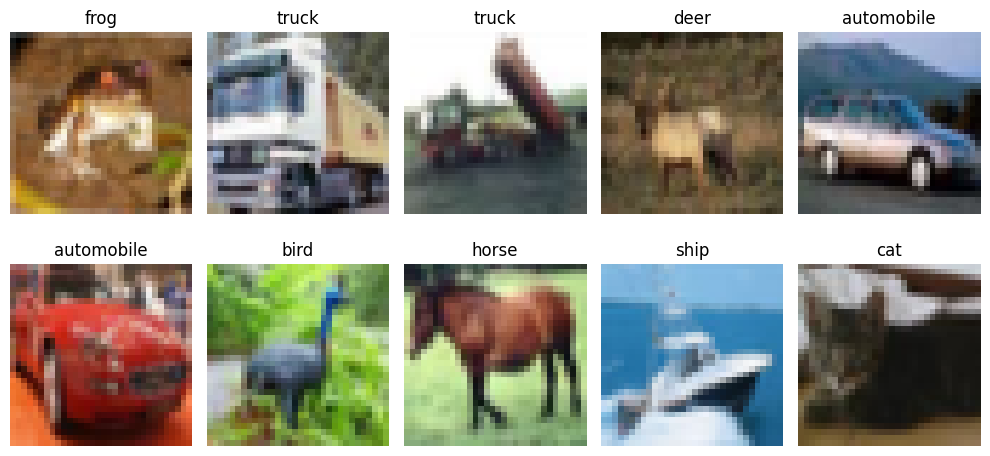

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),   #added more ANN layers
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.2686 - loss: 1.9878 - val_accuracy: 0.3472 - val_loss: 1.8183
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.3211 - loss: 1.8579 - val_accuracy: 0.3648 - val_loss: 1.7954
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3428 - loss: 1.8080 - val_accuracy: 0.3772 - val_loss: 1.7675
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3548 - loss: 1.7773 - val_accuracy: 0.3804 - val_loss: 1.7326
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3645 - loss: 1.7480 - val_accuracy: 0.3790 - val_loss: 1.7171
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3731 - loss: 1.7245 - val_accuracy: 0.3964 - val_loss: 1.7162
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3862 - loss: 1.6954 - val_accuracy: 0.4276 - val_loss: 1.6393
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3894 - loss: 1.6874 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4391 - loss: 1.5925
ANN Test Accuracy: 0.4390999972820282


### Observation: Task 1 (To increase ANN layers)

* **Result:** The test accuracy increased slightly (from ~41% to ~44%).
* **Why it improved:** Adding an extra `Dense` layer with 128 neurons increased the model's overall capacity. With more parameters (weights and biases), the network could learn slightly more complex, non-linear combinations of the pixel values.
* **The Limitation:** Despite the minor improvement, the accuracy is still fundamentally capped. Because the ANN flattens the 2D image into a 1D array, it destroys all spatial relationships (like edges, shapes, and textures). Simply adding more dense layers cannot recover that lost structural context.

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,             #increased epochs from 10 to 20
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop] #added early stopping
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.4703 - loss: 1.4842 - val_accuracy: 0.5620 - val_loss: 1.2205
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.6088 - loss: 1.1187 - val_accuracy: 0.6236 - val_loss: 1.0853
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6709 - loss: 0.9439 - val_accuracy: 0.6146 - val_loss: 1.0949
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7147 - loss: 0.8224 - val_accuracy: 0.6094 - val_loss: 1.1427
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7438 - loss: 0.7297 - val_accuracy: 0.7006 - val_loss: 0.8767
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7703 - loss: 0.6516 - val_accuracy: 0.6994 - val_loss: 0.8989
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 118ms/step - accuracy: 0.7970 - loss: 0.5791 - val_accuracy: 0.7008 - val_loss: 0.9273
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 122ms/step - accuracy: 0.8133 - loss:

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6842 - loss: 0.9250
CNN Test Accuracy: 0.6841999888420105


### Observation: Task 2 (CNN Filters)

* **Note:** The baseline CNN code provided in the notebook already implemented the requested filter progression of `32 → 64 → 128`.
* **Result:** The model trained with these filters achieved a test accuracy of ~71%.
* **Why:** As the spatial dimensions of the image shrink through MaxPooling layers, increasing the number of filters (depth) allows the network to capture increasingly complex, high-level features without losing critical information.

### Observation: Tasks 3 & 4 (Epochs and Early Stopping)

* **Results:**
  * 10 Epochs baseline: ~71.0%
  * 20 Epochs (No Early Stopping): ~73.4%
  * 20 Epochs (With Early Stopping): ~68.4%

* **What happened:** Increasing the epochs to 20 gave the model more time to adjust its weights and learn, which technically bumped the raw test accuracy up to 73.4%. However, running it straight for 20 epochs increases the risk of overfitting, where the model starts memorizing the training images instead of learning general features.

* **Why Early Stopping is useful:** Adding Early Stopping handles this exact risk. It keeps an eye on the validation loss, and when it sees that the validation performance is stalling or getting worse, it cuts off the training early and restores the best weights. Even though the final accuracy dropped slightly to 68.4%, this model is much more stable, less overfit, and will generalize way better to completely new images.

## 📈 Compare Learning Curves

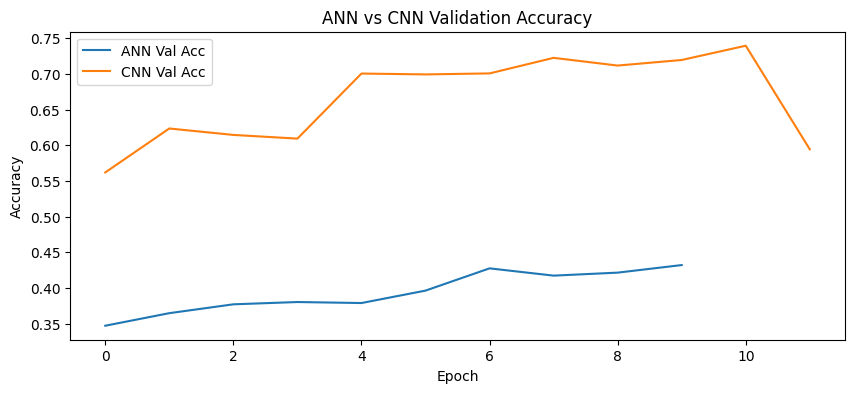

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64)

aug_test_loss, cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.3668 - loss: 1.7370 - val_accuracy: 0.4610 - val_loss: 1.5284
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.4599 - loss: 1.4991 - val_accuracy: 0.5286 - val_loss: 1.2991
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.5015 - loss: 1.4023 - val_accuracy: 0.5680 - val_loss: 1.1856
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5223 - loss: 1.3418 - val_accuracy: 0.5760 - val_loss: 1.1790
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.5424 - loss: 1.2943 - val_accuracy: 0.5928 - val_loss: 1.1370
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.5502 - loss: 1.2699 - val_accuracy: 0.6138 - val_loss: 1.0881
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.5634 - loss: 1.2379 - val_accuracy: 0.6030 - val_loss: 1.0992
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.5732 - loss: 1.2146 - 

### Observation: Task 5 (Data Augmentation)

* **Result:** The augmented model achieved a test accuracy of **65.64%** after 20 epochs.

* **What happened:** Data augmentation applied random flips, rotations, and zooms to the training images on the fly.

* **Why:** At 10 epochs, the accuracy started at 64.2%, and letting it run to 20 epochs allowed it to climb to 65.64%. While this score is lower than the raw baseline model, it highlights a key trade-off: augmentation makes the training data much more complex, meaning the network requires more epochs and capacity to hit maximum accuracy. However, this model is far more robust against overfitting and will perform much more reliably on real-world, unseen images compared to the baseline models.

# 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4391
1,CNN,0.6564


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**